# Initial Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dateutil.relativedelta import *
from numpy.linalg import eigh
from scipy.optimize import minimize
import cvxpy as cp

In [ ]:
data = pd.read_csv("/content/Merged_data_daily.csv", parse_dates = True)
data.head(5)

,Unnamed: 0,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,...,USGG3YR Yield,USDEUR,USDJPY,USDCAD,USDCHF,USDAUD,HG1 Comdty,VNQ US Equity (R1),REIT Index (L1),XAU
0,0,02-01-2015,37.054726,24.214893,41.755470,36.235134,18.539352,74.252625,72.339996,44.354492,...,1.0567,0.8332,120.50,1.1785,1.0017,1.2359,281.75,82.22,1488.29,1188.39
1,1,05-01-2015,36.360405,23.532713,40.969669,36.243198,18.428413,72.998940,71.980003,43.547897,...,1.0378,0.8380,119.64,1.1763,1.0069,1.2369,276.60,82.67,1493.80,1204.86
2,2,06-01-2015,35.793987,23.534939,40.766865,35.831623,18.469618,72.472366,70.529999,42.525681,...,0.9837,0.8410,118.39,1.1836,1.0102,1.2368,276.70,83.49,1506.73,1218.58
3,3,07-01-2015,36.269054,23.864946,42.414536,36.122139,18.577387,73.993523,71.110001,42.972900,...,0.9729,0.8446,119.26,1.1815,1.0143,1.2380,275.85,84.77,1528.85,1211.41
4,4,08-01-2015,37.356197,24.781895,42.858143,36.864601,18.900694,75.121841,72.919998,43.731594,...,0.9701,0.8478,119.66,1.1831,1.0184,1.2311,276.95,85.09,1534.91,1208.79


In [ ]:
# Check if 'Unnamed: 0' column exists and drop it
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

df = data.copy()

# Extract the 'Date' column before calculating log returns
date_column = df['Date']

# Get the columns for which log returns need to be calculated (all columns except 'Date')
value_cols = df.columns.drop('Date')

# Calculate log returns for all value columns at once
log_returns = np.log(df[value_cols] / df[value_cols].shift(1))

# Rename the log return columns to include 'lr_'
log_returns.columns = ["lr_" + col for col in value_cols]

# Combine the 'Date' column with the new log return columns
df = pd.concat([date_column, log_returns], axis=1)

In [ ]:
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

# Defining Necessary Function to build portfolio

In [ ]:
# We need a function that take returns data and delta as input and gives shrunk covariance matrix

def constant_correlation_shrinkage(returns, delta = 0.1):

  X = returns.values
  T, N = X.shape
  S = np.cov(X, rowvar=False)
  std = np.sqrt(np.diag(S))
  corr = S / np.outer(std, std)
  avg_corr = (np.sum(corr) - N) / (N * (N - 1))
  F = avg_corr * np.outer(std, std)
  np.fill_diagonal(F, std ** 2)
  Sigma = (1 - delta) * S + delta * F

  return pd.DataFrame(Sigma, index = returns.columns, columns = returns.columns)

In [ ]:
# Functions to calculate Ledoit Wolf delta and Oracle Approximating delta

def ledoit_wolf_delta(returns):
  X = returns.values
  T, N = X.shape
  S = np.cov(X, rowvar=False)

  mu = np.trace(S) / N
  F = mu * np.eye(N)

  pi_hat = 0
  for t in range(T):
    xt = X[t][:, None]
    outer = xt @ xt.T
    pi_hat += np.sum((outer - S) ** 2)

  pi_hat /= T
  gamma_hat = np.sum((S - F) ** 2)
  delta = min(pi_hat / gamma_hat / T, 1)

  return delta


def oas_delta(returns):
  X = returns.values
  T, N = X.shape
  X = X - X.mean(axis=0)

  S = np.cov(X, rowvar=False)

  trace_S = np.trace(S)
  trace_S2 = np.trace(S @ S)

  num = (1 - 2/N) * trace_S2 + trace_S ** 2
  den = (T + 1 - 2/N) * (trace_S2 - (trace_S**2)/N)

  delta = num / den
  delta = min(delta, 1)
  return delta

In [ ]:
# To calculate covariance matrices

from pandas._libs.tslibs.offsets import delta_to_tick
class Covariance:
  ''' Only feed first-order differenced returns and ensure no date column'''
  def __init__(self, data):
      self.data = data

  def simple_cov(self):
      return self.data.cov()

  def ledoit_wolf(self):
      delta_lw = ledoit_wolf_delta(self.data)
      lw = constant_correlation_shrinkage(self.data, delta=delta_lw)
      return lw

  def oas(self):
      delta_oas = oas_delta(self.data)
      oas  = constant_correlation_shrinkage(self.data, delta=delta_oas)
      return oas

  def shrinkage(self, delta = 0.1):
      return constant_correlation_shrinkage(self.data, delta)

  def spearman_corr(self):
      return self.data.corr(method='spearman')

In [ ]:
# Function that take Covariance Matrix as an input and gives Eigen Values and Eigen Vectors

def give_eigen(cov_matrix):
  eigenvalues, eigenvectors = eigh(cov_matrix)
  idx = eigenvalues.argsort()[::-1]
  eigenvalues = eigenvalues[idx]
  eigenvectors = eigenvectors[:, idx]

  pc_names = [f'PC_{i+1}' for i in range(len(eigenvalues))]
  e_vec_df = pd.DataFrame(eigenvectors, index=cov_matrix.index, columns=pc_names)
  e_val_series = pd.Series(eigenvalues, index=pc_names)

  return e_vec_df, e_val_series

In [ ]:
# Function to find explained variance given a threshold (by default we set it to 0.80 or 80%)

def explained_var(eigen_values, threshold = 0.80):
  exp_var = 0
  for i in range(len(eigen_values)):
    exp_var += (eigen_values.iloc[i] / eigen_values.sum())
    if exp_var >= threshold:
      break
  return eigen_values.iloc[:i]

In [ ]:
# Function to find relevant eigenvalues using Marcenko-Pastur Theorem using the Random Matrix Theory

def marchenko_pastur(eigen_values, obervations):
  n = eigen_values.shape[0]
  T = obervations
  sigma2 = np.mean(eigen_values)
  q = n / T
  lamba_plus = sigma2 * ( (1 + np.sqrt(q)) ** 2  )
  final_eigen_values = eigen_values[eigen_values > lamba_plus]
  return final_eigen_values

In [ ]:
# Function to find asset weights for a long-short portfolio

def pca_risk_parity_closed_form(eigvals, eigvecs, return_factor_weight=False):

    eigvals = np.array(eigvals)
    eigvecs = np.array(eigvecs)

    # PCA factor weights
    y = 1 / np.sqrt(eigvals)

    # Convert to asset weights
    V = eigvecs
    w = V @ y

    # Normalize to sum to 1
    w = w / np.sum(w)

    if return_factor_weight==True:
      return w, y

    return w

In [ ]:
# We will use 'Date' column to find rolling windows

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
# List of Start dates to help us with date filtering
start_date = datetime(2015,1,1)    # Setting a start date
start_date_list = [start_date]     # Storing start dates in a list

for i in range(0,72):              # Iterating 60 times with the start dates increased by 1 month at each iteration
    start_date = start_date +relativedelta(months=+1)
    start_date_list.append(start_date)
# The result is a list of start dates


# List of End dates to help us with date filtering
end_date = datetime(2020,1,1)     # Setting an end date
end_date_list = [end_date]        # Storing end dates in a list

for i in range(0,72):             # Iterating 60 times with the end dates increased by 1 month at each iteration
    end_date = end_date +relativedelta(months=+1)
    end_date_list.append(end_date)
# The result is a list of end dates

In [ ]:
def give_weights(data, cov_method, eigen_filtering, delta = 0.1, threshold = 0.80, return_factor_weight=False):

  weights_df = pd.DataFrame()

  for i in range(72):
    window = data[data['Date'] > start_date_list[i]]        # Filtering for start time
    window = window[window['Date'] < end_date_list[i]]      # Filtering for end time
    window = window.iloc[:,1:]

    running_month = end_date_list[i].month
    running_year = end_date_list[i].year
    running_time = str(running_month) + '_' + str(running_year)

    cov = Covariance(window)

    if cov_method == 'simple':
      cov_ = cov.simple_cov()

    elif cov_method == 'ledoit_wolf':
      cov_ = cov.ledoit_wolf()

    elif cov_method == 'oas':
      cov_ = cov.oas()

    elif cov_method == 'shrinkage':
      cov_ = cov.shrinkage(delta = delta)

    elif cov_method == 'spearman':
      cov_ = cov.spearman_corr()

    else:
      print("Invalid cov_method input. Select either 'simple', 'ledoit_wolf', 'oas', 'shrinkage', or 'spearman'.")
      break

    eigen_vec, eigen_val = give_eigen(cov_)

    if eigen_filtering == 'explained_var':
      eval = explained_var(eigen_val, threshold = threshold)
      count_e = eval.shape[0]
      evec = eigen_vec.loc[:,eval.index]

    elif eigen_filtering == 'marchenko_pastur':
      T = window.shape[0]
      eval = marchenko_pastur(eigen_val, T)
      count_e = eval.shape[0]
      evec = eigen_vec.loc[:,eval.index]

    else:
      print("Invalid eigen_filtering input. Select either 'explained_var', or 'marchenko_pastur'.")
      break

    weights = pca_risk_parity_closed_form(eval, evec, return_factor_weight=return_factor_weight)

    weights_df.index = evec.index
    weights_df[running_time] = weights

  return weights_df

# Calculating weights for all combination of portfolios

In [ ]:
give_weights(df, 'simple', 'marchenko_pastur')

,1_2020,2_2020,3_2020,4_2020,5_2020,6_2020,7_2020,8_2020,9_2020,10_2020,...,3_2025,4_2025,5_2025,6_2025,7_2025,8_2025,9_2025,10_2025,11_2025,12_2025
lr_A,0.002762,0.004125,-0.011218,0.002674,-0.014997,-0.016934,-0.009831,0.005061,0.004644,-0.012056,...,-0.083446,-0.017558,0.113051,-0.004845,0.001509,-0.449150,-0.008435,0.021216,-0.003964,-0.047643
lr_AAPL,0.005428,0.029126,0.005326,-0.029194,0.013822,0.013750,0.015249,-0.005657,-0.009642,0.005408,...,-0.017133,-0.001138,0.073091,0.006985,0.022771,-2.078564,-0.053040,0.044584,0.040121,0.052880
lr_ABBV,-0.019969,-0.031326,-0.017286,0.028964,-0.032175,-0.030956,-0.017284,-0.022090,-0.004612,-0.017665,...,-0.006713,-0.001001,0.092816,-0.005695,0.025777,-2.103983,0.012947,0.039393,0.015586,0.011487
lr_ABT,0.001840,-0.008708,-0.002216,-0.014684,-0.005123,-0.002536,-0.006340,-0.001195,0.005294,-0.011143,...,0.009281,0.019448,-0.014307,-0.010639,-0.011353,-0.309348,-0.006011,0.029794,0.023216,-0.004682
lr_ACGL,0.017569,0.008395,-0.008976,0.011363,-0.020577,-0.027235,-0.004956,0.002429,0.004105,0.005128,...,0.098716,0.049242,-0.135556,0.059190,0.033864,1.665181,0.087141,-0.024345,0.078364,0.050176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lr_USDAUD,-0.011235,0.002405,-0.009299,-0.002135,-0.007348,-0.003128,-0.002440,-0.008012,-0.005158,-0.000363,...,0.001724,0.024132,-0.039640,-0.008520,0.019749,0.125070,-0.050393,-0.020297,-0.011400,0.039868
lr_HG1 Comdty,0.004938,-0.025457,0.028410,-0.001116,0.032362,0.019824,0.003629,0.017120,0.011233,-0.002349,...,0.028783,-0.096429,0.195972,0.038590,-0.039008,-0.082620,0.072081,0.050851,0.019773,-0.139780
lr_VNQ US Equity (R1),-0.001795,0.013212,-0.019939,0.031100,0.001981,0.007424,-0.003071,-0.007541,-0.011787,-0.007468,...,-0.105666,-0.073623,0.090858,-0.020959,-0.030002,0.326338,0.001358,-0.028792,0.038894,0.029848
lr_REIT Index (L1),0.000123,0.014015,-0.019753,0.031480,0.001117,0.005988,-0.002735,-0.007926,-0.012714,-0.007349,...,-0.106882,-0.078094,0.098400,-0.021652,-0.030919,0.242938,-0.001688,-0.027357,0.042991,0.032881


In [ ]:
# Running this code will take some time, be patient.
# Expect 2 to 5 minutes of execution time

# Simple Covariance Estimation with Explained Variance filtering at 80%
port_sim_cov_expl = give_weights(df, 'simple', 'explained_var', threshold=0.80)

# Simple Covariance Estimation with Marcenko Pastur filtering
port_sim_cov_mp = give_weights(df, 'simple', 'marchenko_pastur')

# Ledoit-Wolf Covariance Estimation with Explained Variance filtering at 80%
port_lw_cov_expl = give_weights(df, 'ledoit_wolf', 'explained_var', threshold=0.80)

# Oracle Approximating Covariance Estimation with Explained Variance filtering at 80%
port_oas_cov_expl = give_weights(df, 'oas', 'explained_var', threshold=0.80)

# Custom Covariance Shrinkage at delta = 0.2 with Explained Variance filtering at 80%
port_cus_cov_expl = give_weights(df, 'shrinkage', 'explained_var', delta=0.2, threshold=0.80)

# Custom Covariance Shrinkage at delta = 0.2 with Marcenko Pastur filtering
port_cus_cov_mp = give_weights(df, 'shrinkage', 'marchenko_pastur', delta=0.2)

# Spearman Correlation with Explained Variance filtering at 80%
port_spr_cor_expl = give_weights(df, 'spearman', 'explained_var', threshold=0.80)

In [ ]:
jan2020_port = pd.DataFrame()
jan2020_port['Simple_Cov_Explained_Var']              = port_sim_cov_expl['1_2020']
jan2020_port['Simple_Cov_MP']                         = port_sim_cov_mp['1_2020']
jan2020_port['LedoitWOld_Cov_Explained_Var']          = port_lw_cov_expl['1_2020']
jan2020_port['OracleApproximating_Cov_Explained_Var'] = port_oas_cov_expl['1_2020']
jan2020_port['Custom_Cov_Shr_Explained_Var']          = port_cus_cov_expl['1_2020']
jan2020_port['Custom_Cov_Shr_MP']                     = port_cus_cov_mp['1_2020']
jan2020_port['Spr_Corr_Explained_Var']                = port_spr_cor_expl['1_2020']

In [ ]:
jan2020_port

,Simple_Cov_Explained_Var,Simple_Cov_MP,LedoitWOld_Cov_Explained_Var,OracleApproximating_Cov_Explained_Var,Custom_Cov_Shr_Explained_Var,Custom_Cov_Shr_MP,Spr_Corr_Explained_Var
lr_A,-0.025218,0.002762,-0.017709,-0.006101,-0.082585,0.002408,-0.057504
lr_AAPL,0.129653,0.005428,0.094222,0.118040,-0.188625,-0.019523,-0.429086
lr_ABBV,-0.263327,-0.019969,-0.203655,-0.212953,-0.302421,-0.013161,-0.611904
lr_ABT,0.028242,0.001840,0.026042,0.004741,-0.104751,-0.012445,-0.180890
lr_ACGL,0.042927,0.017569,0.085808,0.054698,-0.192567,0.016293,0.080201
...,...,...,...,...,...,...,...
lr_USDAUD,0.023097,-0.011235,0.017040,0.014622,0.028383,-0.007541,0.304889
lr_HG1 Comdty,-0.034421,0.004938,0.035021,0.023927,-0.267813,-0.026490,-0.091293
lr_VNQ US Equity (R1),0.023453,-0.001795,0.017673,0.017839,-0.012351,0.018328,0.036369
lr_REIT Index (L1),0.018328,0.000123,0.010447,0.013569,-0.002243,0.020390,-0.130048


In [ ]:
port_cus_cov_mp['1_2020'].max()

0.17128475882578975

In [ ]:
port_spr_cor_expl['1_2020'].max()

1.4060490233200997

In [ ]:
jan2020_port = pd.DataFrame()
jan2020_port['Simple_Cov_Expl_Var']        = port_sim_cov_expl['1_2020']
jan2020_port['Simple_Cov_MP']              = port_sim_cov_mp['1_2020']
jan2020_port['LedoitWOld_Cov_Expl_Var']    = port_lw_cov_expl['1_2020']
jan2020_port['OracleApprox_Cov_Expl_Var']  = port_oas_cov_expl['1_2020']
jan2020_port['Custom_Cov_Shr_Expl_Var']    = port_cus_cov_expl['1_2020']
jan2020_port['Custom_Cov_Shr_MP']          = port_cus_cov_mp['1_2020']
jan2020_port['Spr_Corr_Expl_Var']          = port_spr_cor_expl['1_2020']



In [ ]:
for col in jan2020_port.columns:
    min_ , max_ = jan2020_port[col].min() , jan2020_port[col].max()
    print(f"{col} Max : {max_:.2f} Min : {min_:.2f}")

Simple_Cov_Expl_Var Max : 0.37 Min : -0.56
Simple_Cov_MP Max : 0.11 Min : -0.11
LedoitWOld_Cov_Expl_Var Max : 0.31 Min : -0.46
OracleApprox_Cov_Expl_Var Max : 0.27 Min : -0.45
Custom_Cov_Shr_Expl_Var Max : 1.22 Min : -1.26
Custom_Cov_Shr_MP Max : 0.17 Min : -0.24
Spr_Corr_Expl_Var Max : 1.41 Min : -1.95


In [ ]:
port_cust_cov_expl.describe()

,1_2020,2_2020,3_2020,4_2020,5_2020,6_2020,7_2020,8_2020,9_2020,10_2020,...,3_2025,4_2025,5_2025,6_2025,7_2025,8_2025,9_2025,10_2025,11_2025,12_2025
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,...,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,...,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110
std,0.242435,0.198766,0.099245,0.122315,0.424295,0.070916,0.170293,0.107938,0.084180,0.068119,...,0.480581,0.464416,0.155708,15.549833,0.206571,0.789400,0.561053,1.667998,0.232446,0.139668
min,-1.261045,-0.618330,-0.410696,-0.469217,-2.477232,-0.383685,-0.847306,-0.580763,-0.334845,-0.259885,...,-1.561041,-2.660127,-0.653631,-60.707306,-0.815816,-4.078973,-2.284060,-7.586346,-1.314913,-0.443392
25%,-0.104272,-0.093842,-0.040274,-0.058235,-0.219524,-0.027630,-0.075885,-0.043453,-0.037610,-0.036734,...,-0.292614,-0.208151,-0.084777,-7.556819,-0.103304,-0.382953,-0.304676,-0.808204,-0.126538,-0.064290
50%,-0.002707,-0.001683,0.000479,0.003611,0.009412,0.002802,-0.005628,-0.000572,0.005672,0.002767,...,-0.016312,0.013296,-0.001545,0.337304,0.011073,0.008086,-0.025851,-0.074715,-0.016450,0.005543
75%,0.114423,0.104050,0.052712,0.060518,0.230611,0.038478,0.072669,0.049327,0.040107,0.041432,...,0.245412,0.249803,0.088144,7.458737,0.122667,0.396627,0.296578,0.727090,0.125541,0.076259
max,1.223340,0.781930,0.374044,0.550880,1.570950,0.342431,0.681374,0.519650,0.411557,0.219564,...,2.562363,1.516208,0.785025,99.176577,0.723393,2.638506,2.198909,5.375010,0.993998,0.556155


In [ ]:
port_spr_cor_expl.describe()

,1_2020,2_2020,3_2020,4_2020,5_2020,6_2020,7_2020,8_2020,9_2020,10_2020,...,3_2025,4_2025,5_2025,6_2025,7_2025,8_2025,9_2025,10_2025,11_2025,12_2025
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,...,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,...,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110,0.002110
std,0.506845,0.230071,0.114576,0.122912,0.098894,0.210801,0.263632,0.237618,0.065274,0.320488,...,0.081957,1.484581,0.092789,0.068785,0.212370,0.345638,0.300712,0.261097,0.072721,0.112133
min,-1.953685,-0.842312,-0.363389,-0.373525,-0.296552,-0.821131,-0.922790,-0.838121,-0.222805,-1.244000,...,-0.217934,-6.966667,-0.231930,-0.269550,-0.708832,-1.430112,-0.843105,-0.949076,-0.236710,-0.327100
25%,-0.320588,-0.143273,-0.067510,-0.075835,-0.061362,-0.127320,-0.158547,-0.146378,-0.038286,-0.193344,...,-0.047258,-0.776767,-0.064044,-0.043507,-0.119519,-0.198247,-0.197315,-0.165770,-0.043603,-0.073385
50%,-0.030841,0.011946,-0.001843,-0.003559,-0.005018,0.007554,0.012425,-0.007614,0.002742,0.003004,...,0.002828,-0.040579,0.006492,0.004274,-0.003357,0.004416,-0.009092,0.012291,0.002706,-0.001165
75%,0.297404,0.131517,0.070673,0.077854,0.060931,0.144296,0.167352,0.153792,0.044845,0.195835,...,0.057273,0.804737,0.066050,0.045656,0.144120,0.206063,0.195708,0.157312,0.049128,0.065309
max,1.406049,0.978678,0.372228,0.436562,0.332071,0.791916,0.941240,0.769494,0.246122,1.018150,...,0.388198,6.911329,0.327540,0.246879,0.961672,1.107657,0.892463,0.799114,0.255977,0.527170


In [ ]:
give_weights(df, 'shrinkage', 'explained_var', delta=0.2, threshold=0.80, return_factor_weight=True)

ValueError: Length of values (2) does not match length of index (474)

In [ ]:
port_lw_cov_expl.describe().iloc['max',:]

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [ ]:
pd.DataFrame(port_sim_cov_mp.describe()).loc['max',:].sort_values(ascending=False)

,max
8_2025,20.194038
5_2025,1.296677
2_2024,0.867101
1_2024,0.570284
11_2025,0.498429
...,...
4_2022,0.085486
7_2021,0.084038
10_2022,0.079780
9_2022,0.076344


<Axes: >

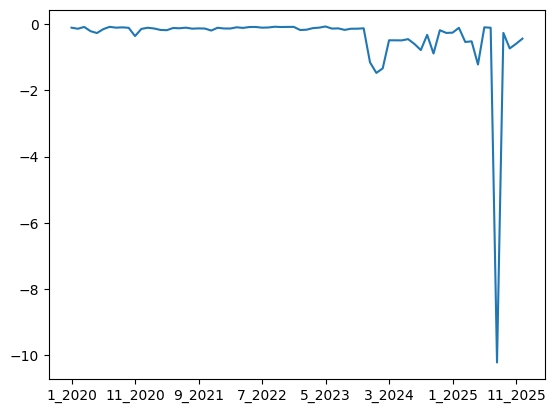

In [ ]:
pd.DataFrame(port_sim_cov_mp.describe()).loc['min',:].plot.line()

<Axes: >

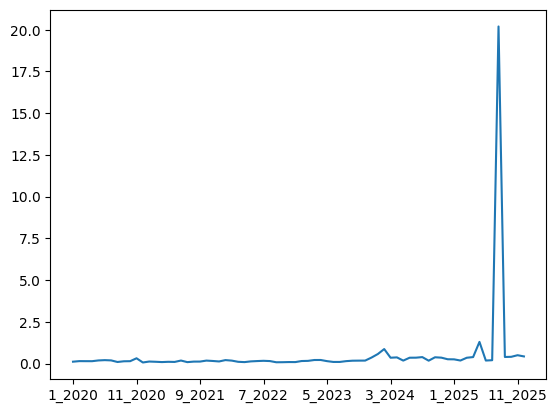

In [ ]:
pd.DataFrame(port_sim_cov_mp.describe()).loc['max',:].plot.line()

<Axes: >

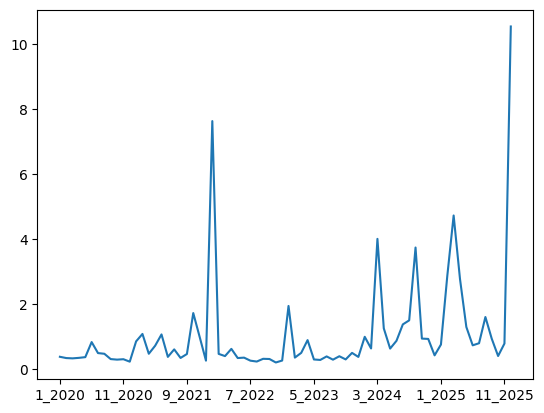

In [ ]:
pd.DataFrame(port_sim_cov_expl.describe()).loc['max',:].plot.line()

<Axes: >

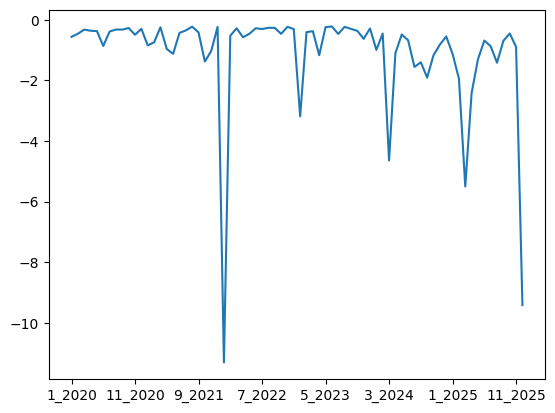

In [ ]:
pd.DataFrame(port_sim_cov_expl.describe()).loc['min',:].plot.line()

<Axes: >

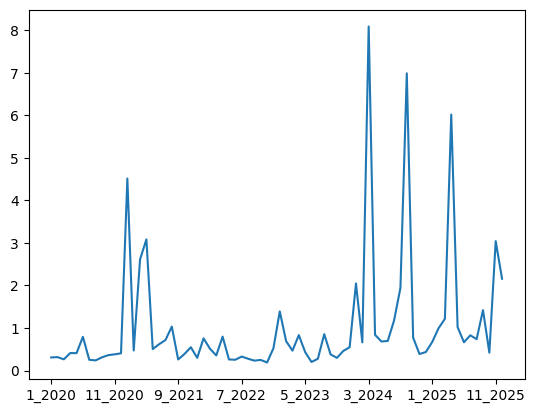

In [ ]:
pd.DataFrame(port_lw_cov_expl.describe()).loc['max',:].plot.line()

<Axes: >

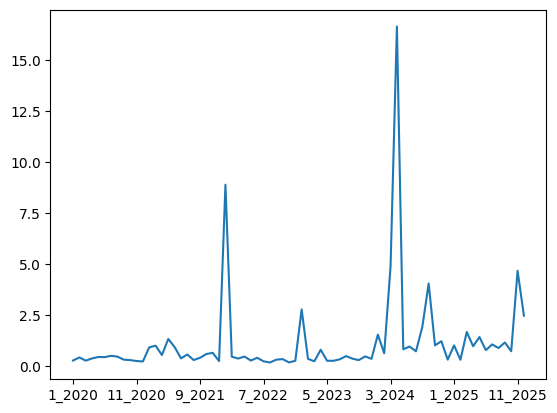

In [ ]:
pd.DataFrame(port_oas_cov_expl.describe()).loc['max',:].plot.line()

<Axes: >

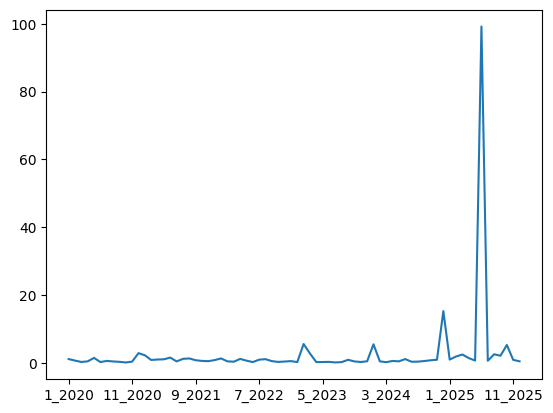

In [ ]:
pd.DataFrame(port_cust_cov_expl.describe()).loc['max',:].plot.line()

<Axes: >

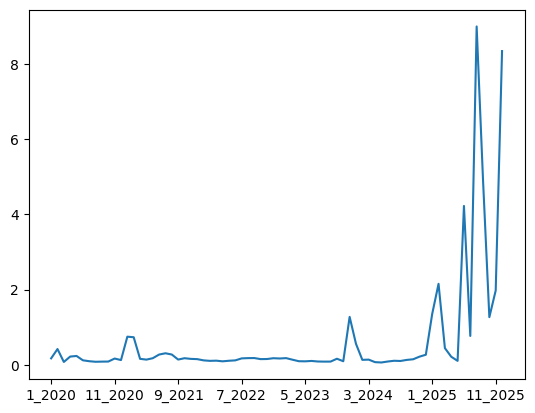

In [ ]:
pd.DataFrame(port_cust_cov_mp.describe()).loc['max',:].plot.line()

<Axes: >

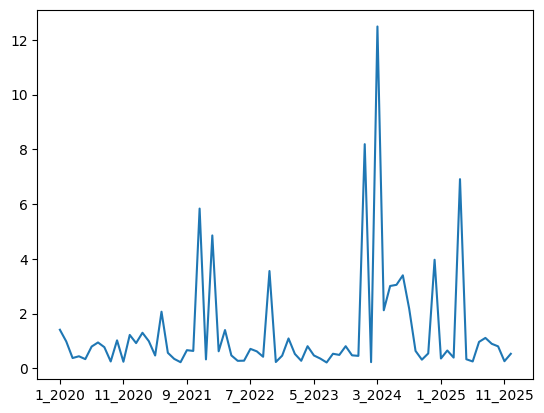

In [ ]:
pd.DataFrame(port_spr_cor_expl.describe()).loc['max',:].plot.line()